# Третий блок. MLP модель

### Импорт библиотек

In [ ]:
pip install scikit-learn matplotlib numpy pandas

In [2]:
import pandas as pd # Работа с csv данными
import numpy as np 
import matplotlib.pyplot as plt # Построение графиков
from sklearn.preprocessing import StandardScaler, label_binarize # Стандартизация признаков, преобразование меток в бинарный вид
from sklearn.neural_network import MLPClassifier # Новый модуль для работы с MLP
from sklearn.metrics import ( classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score ) # Метрики
import joblib # Сохранение модели
import time

### Объединение 4 и 5 классов в один (сидение + стояние)

In [ ]:
import pandas as pd
train_df = pd.read_csv("features_train.csv")
test_df = pd.read_csv("features_test.csv")

# Объединение классов 4 и 5 в класс 4 (сидение+стояние)
# Заменяем все 5 на 4
train_df["Activity"] = train_df["Activity"].replace({5: 4})
test_df["Activity"] = test_df["Activity"].replace({5: 4})

# Сохранение новых файлов
train_df.to_csv("features_train_5class.csv", index=False)
test_df.to_csv("features_test_5class.csv", index=False)


### Подгрузка подготовленных признаков для обучения моделей

In [5]:
train_df = pd.read_csv("features_train_5class.csv")
test_df = pd.read_csv("features_test_5class.csv")
# Разделяем входные данные и соответствующие классы
X_train = train_df.drop("Activity", axis=1) # Матрица признаков с удалением 1 колонки (т.е. номер класса)
y_train = train_df["Activity"] # Целевая переменная
X_test = test_df.drop("Activity", axis=1)
y_test = test_df["Activity"]

### Стандартизация признаков 

In [7]:
standarter = StandardScaler()
X_train_standart = standarter.fit_transform(X_train)
X_test_standart = standarter.transform(X_test) # Не пересчитываем параметры на тестовых данных

### Обучение MLP

In [ ]:
# MLP с 2 скрытыми слоями 64 и 32 (степени двойки для оптимизации под железо + умеренные числа), ReLU, Adam
mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation="relu", # Функция активации ReLU широко распространена на практике и работает быстро
    solver="adam", # Плюсы: хорошо борется с шумами, не требует ручной настройки, быстро сходится
    early_stopping=True, # Защита от переобучения
    random_state=42,
)

mlp.fit(X_train_standart, y_train) # Обучение
joblib.dump(mlp, "mlp_model.pkl") # Сохранение

Время обучения: 7.6197206000069855 сек


['mlp_model.pkl']

### Предсказание по тествовым данным и замер времени предсказания нового примера (среднее значение)

In [250]:
start_time = time.perf_counter()
y_pred = mlp.predict(X_test_standart)
all_time = (time.perf_counter()-start_time)*1000  # в миллисекундах
avg_time = all_time / len(y_test) 

### Метрики MLP модели
#### Стандартный Precision | Recall | F1-score, Accuracy, F1-Score(macro), Время инференса, Матрица ошибок (для сравнения между похожими классами)

In [251]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.54      0.65      0.59       657
           1       0.88      0.85      0.86      2078
           2       0.99      0.79      0.88       328
           3       0.78      1.00      0.88       265
           4       0.89      0.87      0.88      4075

    accuracy                           0.85      7403
   macro avg       0.81      0.83      0.82      7403
weighted avg       0.86      0.85      0.85      7403



In [252]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy for test.csv: {acc}")

Accuracy for test.csv: 0.8469539375928677


In [253]:
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"F1-score (macro): {f1_macro}")

F1-score (macro): 0.8179197629363057


In [ ]:
print(f"Avg inference time: {avg_time} 10^(-3)*second ")

Avg inference time: 0.0008384303657676937 10^(-3)*second 


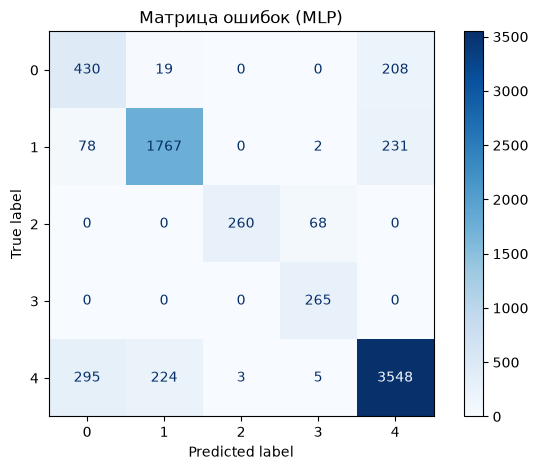

[[ 430   19    0    0  208]
 [  78 1767    0    2  231]
 [   0    0  260   68    0]
 [   0    0    0  265    0]
 [ 295  224    3    5 3548]]


In [255]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(set(y_test)))
disp.plot(cmap="Blues")
plt.title("Матрица ошибок (MLP)")
plt.tight_layout()
plt.savefig("mlp_confusion_matrix.png")
plt.show()
print(cm)

### Построение графиков обучения

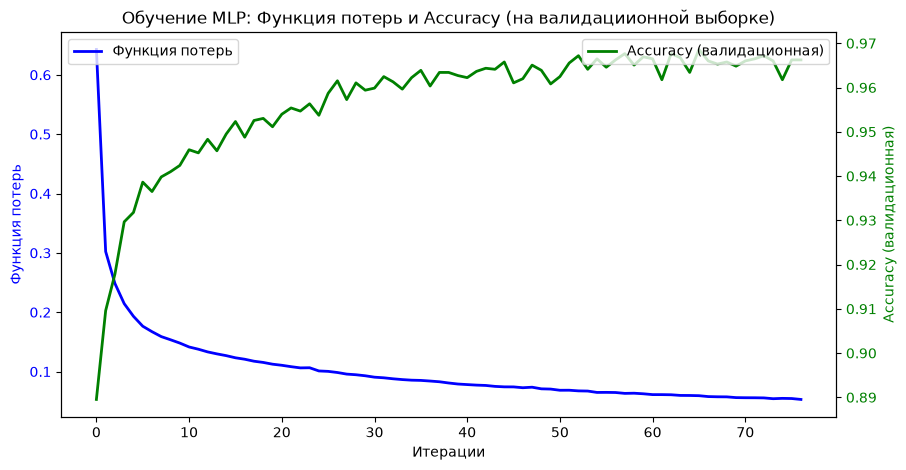

In [12]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=200,
    learning_rate_init=0.001,
    max_iter=300,                 
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42,
)

mlp.fit(X_train_standart, y_train)

fig, ax1 = plt.subplots(figsize=(10, 5))


ax1.plot(mlp.loss_curve_, label="Функция потерь", color="blue", linewidth=2)
ax1.set_xlabel("Итерации")
ax1.set_ylabel("Функция потерь", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.legend(loc="upper left")


ax2 = ax1.twinx()
ax2.plot(mlp.validation_scores_, label="Accuracy (валидационная)", color="green", linewidth=2)
ax2.set_ylabel("Accuracy (валидационная)", color="green")
ax2.tick_params(axis="y", labelcolor="green")
ax2.legend(loc="upper right")

plt.title("Обучение MLP: Функция потерь и Accuracy (на валидациионной выборке)")
plt.show()

